# Grundlagen - Lösungen


## Übersicht


Dieses Notebook behandelt die Grundlagen der numerischen Mathematik:

1. Kontinuierliche und diskrete Funktionen, Folgen und iterative Prozesse
2. Zahlendarstellung im Computer (Dezimal-, Binär- und Gleitkommadarstellung)
3. Verschiedene Fehlertypen (Darstellungs-, Rechen-, Diskretisierungs- und Messfehler)


## 1. Kontinuierlich, Diskret, Iterativ


### Kontinuierliche Funktionen / Prozesse


Physikatische Grössen sind sehr häufig **kontinuierlich**, d.h. sie ändern sich nicht sprunghaft. Beispiele:

- Temperatur einer Flüssigkeit
- Konzentration einer eines Stoffes in einer Lösung
- Leistung einer Batterie

In der Mathematik sprechen wir dann von **stetigen** Funktionen. Dabei macht ein **stetiger** Funktionsgraph **keine Sprünge** und hat **keine Lücken**.

Als Beispiel betrachten wir die Funktion

$$
f(x) = x^2 e^{-x}
$$


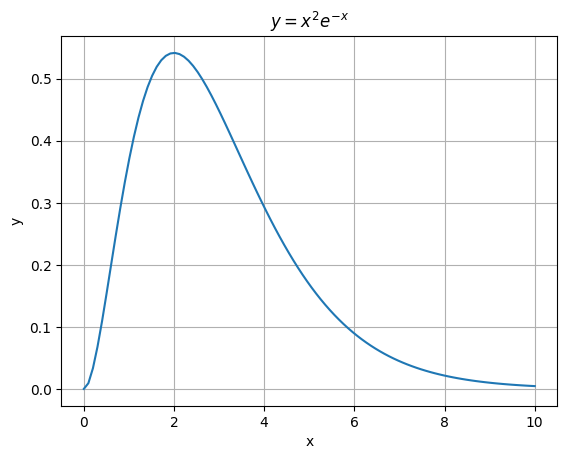

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 10, num=100)
y = x**2 * np.exp(-x)

plt.plot(x, y)
plt.grid()
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"$y = x^2 e^{-x}$")
plt.show()

_Bemerkung:_ Berechnet man die Funktion nur an an wenigen Stellen, so wird ersichtlich, dass [`matplotlib.pyplot.plot`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html) die Punkte mit Geraden miteinander verbindet, also **linear interpoliert**. Für kontinuierliche Funktionen ist dies sinnvoll, weil ja wirklich alle Werte zwischen zwei Punkten irgendwann mal angenommen werden (Zwischenwertsatz).


### Diskrete Funktionen / Prozesse


Andere Grössen können nur **spezifische Werte** (meist ganze Zahlen) annehmen. Wir sprechen von **diskreten Werten**. Beispiele:

- Anzahl Bäume in einem Waldstück
- Anzahl weisse Blutkörperchen in einer Blutprobe
- Anzahl Blutprobenröhrchen in einer Warteschlange vor einem Analysegerät
- Energieniveaus von Elektronen in Atomen
- Zustand des Analysegeräts (0=idle, 1=busy, 2=blocked)

Die entsprechenden mathematischen Funktionen können **nur ganzzahlige Werte** annehmen (Wertebereich $W\subseteq\mathbb{Z}$), müssen daher **Sprungstellen** haben und können somit **nicht stetig** sein.

Als Beispiel simulieren wir einen stochastischen Prozess, bei dem sich der diskrete Zustand $z$ an zufälligen Zeitpunkten $t$ ändert. Dies könnte z.B. die Anzahl Personen in einem Raum im Zeitverlauf sein. Hier ist die Zeit kontinuierlich und der Zustand diskret.


In [2]:
rng = np.random.default_rng(42)
rng.uniform(low=3, high=5, size=10)

array([4.5479121 , 3.87775688, 4.71719584, 4.39473606, 3.1883547 ,
       4.9512447 , 4.5222794 , 4.57212861, 3.25622727, 3.90077188])

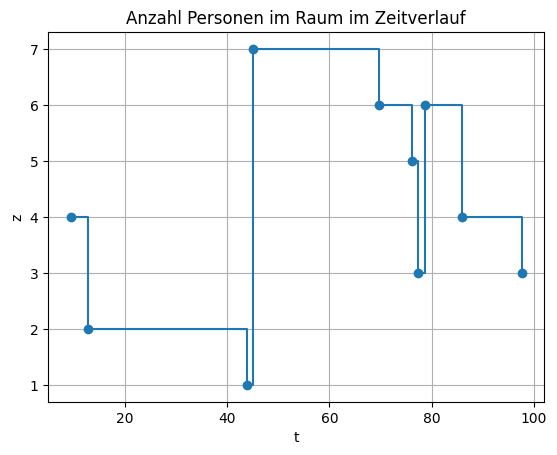

In [3]:
rng = np.random.default_rng(42)
t = np.sort(rng.uniform(high=100, size=10))
z = rng.integers(low=0, high=8, size=len(t))

plt.step(t, z, "o-", where="post")
plt.xlabel("t")
plt.ylabel("z")
plt.title("Anzahl Personen im Raum im Zeitverlauf")
plt.grid()
plt.show()

_Bemerkung:_ Für die Darstellung einer diskreten Funktion benutzen wir [`matplotlib.pyplot.step`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.step.html), weil Sprünge als senkrechte Linien darstellt werden, anstatt die Punkte diagonal zu verbinden (also linear zu interpolieren) wie dies [`matplotlib.pyplot.plot`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html) macht.


### Folgen / Iterative Prozesse


Schliesslich gibt es auch Prozesse, die mit konstanten (diskreten) Schritten verlaufen. Hier ist der Fortschritt des Prozesses eine Anzahl Schritte, auch **Iterationen** genannt. In manchen Fällen sind dies Zeitschritte gleicher Schrittlänge, in anderen Fällen aber auch nicht. Solche Prozesse sind aus der Mathematik als **Folgen** bekannt.

Ein Beispiel ist die [**logistische Gleichung**](https://de.wikipedia.org/wiki/Logistische_Gleichung)

$$
x_{n+1} = r x_n (1 - x_n)
$$

Sie ist ein Modell von beschränktem Populationswachstum mit einer Wachstumsrate $r$. Für $r$-Werte grösser als ca. 3.6 kann die Folge spannendes chaotisches Verhalten zeigen.


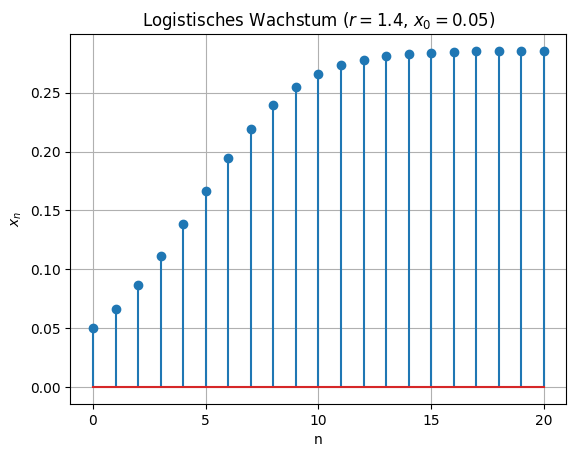

In [4]:
r = 1.4
x0 = 0.05
N = 20


def logistisch(r, x0, N):
    xn = x0
    x = [x0]
    for _ in range(N):
        xn = r * xn * (1 - xn)
        x.append(xn)
    return x


x = logistisch(r, x0, N)

fig, ax = plt.subplots()
ax.stem(x)
# ax.plot(x, 'o')
ax.xaxis.set_ticks(np.arange(N + 1, step=round(N / 4)))
ax.grid()
ax.set_xlabel("n")
ax.set_ylabel("$x_n$")
plt.title(f"Logistisches Wachstum ($r={r}$, $x_0={x0}$)")
plt.show()

Hier sind die $n$-Werte auf der horizontalen Achse **diskret** und $x_n$-Werte auf der vertikalen Achse **kontinuierlich**. Das heisst, zwischen den dargestellten Punkten existieren keine weiteren Punkte. Darum sollten die Punkte auch nicht verbunden werden.

Für die Darstellung bietet sich daher die Funktion [`matplotlib.pyplot.stem`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.stem.html) an, welche mit den senkrechten Stäben etwas verdeutlicht, dass es sich um diskrete $n$-Schritte handelt. Alternativ können auch einfach nicht-verbundene Punkte verwendet werden: `plt.plot(x, 'o')`.


### Daten


Data Scientists arbeiten häufig mit Daten und nicht nur mit Modellen, die in Form von stetigen, stochastischen oder iterativen Prozessen daher kommen. Daten sind allerdings Beobachtungen von Variablen, deren Ausprägungen entweder kontinuierlich oder diskret sind, siehe _Skalenniveau_ im Modul _Daten und Information_. Beim Darstellen von und Rechnen mit Daten ist es daher wichtig, die geeigneten Tools und Methoden einzusetzen.


## 2. Zahlendarstellung


Wir werfen einen kleinen Blick auf die Darstellung von Zahlen im Computer, um etwas besser zu verstehen, wie genau oder eben ungenau Computer rechnen können.


### Dezimalsystem, Binärsystem, b-adisches System


Die Zahl **173** lässt sich im **Dezimalsystem** schreiben als

$$
173.02 = 1 \cdot 10^2 + 7 \cdot 10^1 + 3 \cdot 10^0 + 1\cdot 10^{-2}
$$

Analog funktioniert das **Binärsystem**, in dem ein Computer Zahlen darstellen und damit rechnen kann:

$$
1101_{(2)} = 1 \cdot 2^3 + 1 \cdot 2^2 + 0 \cdot 2^1 + 1 \cdot 2^0 = 13_{(10)}
$$

Allgemein können reelle Zahlen $x\in\mathbb{R}$ bezüglich einer beliebigen Basis $b\in \mathbb{N}$ mit $b\geq 2$ dargestellt werden

$$
x = \pm \sum_{k=-\infty}^\infty z_k \cdot b^k
$$

Hier sind $z_k\in\{0,1,\ldots,b-1\}$ die Ziffern. Für eine allgemeine Basis $b$ spricht man vom **b-adischen Stellenwertsystem**.

Noch ein Beispiel im Binärsystem ($b=2$ und $z_k\in\{0,1\}$): Wir können auch binäre (oder dyadische) Brüche darstellen

\begin{align*}
100110.01_{(2)}
&= 1 \cdot 2^5 &&+ 0 \cdot 2^4 &&+ 0 \cdot 2^3 &&+ 1 \cdot 2^2 &&+ 1 \cdot 2^1 &&+ 0 \cdot 2^0 &&+ 0 \cdot 2^{-1} &&+ 1 \cdot 2^{-2} \\
&= 1 \cdot 32 &&+ 0 \cdot 16 &&+ 0 \cdot 8 &&+ 1 \cdot 4 &&+ 1 \cdot 2 &&+ 0 \cdot 1 &&+ 0 \cdot \frac{1}{2} &&+ 1 \cdot \frac{1}{4} \\
&= 32 &&+ 0 &&+ 0 &&+ 4 &&+ 2 &&+ 0 &&+ \frac{1}{4} \\
&= 38.25_{(10)}
\end{align*}

Die Umrechnung vom Dezimal- ins Binärsystem geschieht über die fortgesetzte Division mit Rest. Als Beispiel nehmen wir $x=12.5_{(10)}$:

1. Suche den grössten Exponenten $n$ mit $2^n \leq x$. Wir finden $n=3$, weil $2^3 = 8 < x$ und $2^4 = 16 > x$.
2. Die erste 1 in der gesuchten Binärdarstellung ist also an 4. Stelle, $1000_{(2)}$, da zuhinterst die 0. Stelle ist.
3. Wir wiederholen den Vorgang mit dem Rest $x_1 = x - 2^n = 12.5 - 8 = 4.5$: Wir finden $n=2$ mit $2^2 = 4 = 100_{(2)}$.
4. Und nochmals mit dem $x_2 = x_1 - 2^n = 4.5 - 4 = 0.5$: Wir finden $n=-1$ mit $2^{-1} = 0.5 = 0.1_{(2)}$.

Alles in allem erhalten wir:

$$
x = 12.5 = 1000_{(2)} + 100_{(2)} + 0.1_{(2)} = 1100.1_{(2)}
$$

Weitere Beispiele sind hier zu finden:

- [Video "p-adische Zahlendarstellung - Daten- und Zeichendarstellung 2", simpleclub](https://youtu.be/WzqlPXslQL8)
- [Numerik 1, Wikiversity](https://de.wikiversity.org/wiki/Kurs:Numerik_I/Besonderheiten_des_numerischen_Rechnens#Bemerkung_-_Umrechnungsverfahren)

Online-Rechner für Umrechnungen: https://www.matheretter.de/rechner/dezimalbinar


### Gleitkommadarstellung (Floating Point)


In Computern wird mit der Gleitkommadarstellung reeller Zahlen bezüglich der Basis 2 gearbeitet:

$$
x = v \cdot m \cdot b^e
$$

Da der Speicher endlich ist, kann nur eine gewisse Anzahl Bits (binäre Ziffern) verwendet werden. Eine Konvention ist die Folgende (IIEEE 754 double):

| Symbol | Bezeichnung | Bereich        | Bits |
| ------ | ----------- | -------------- | ---- |
| $v$    | Vorzeichen  | $\{+1, -1\}$   | 1    |
| $m$    | Mantisse    | $\mathbb{N}_0$ | 52   |
| $b$    | Basis       | $\{2, 10\}$    | 0    |
| $e$    | Exponent    | $\mathbb{Z}$   | 11   |

- 52 Bit für die Mantisse bedeut, dass die grösste darstellbare Mantisse $m_\text{max} = 2^{52} - 1 = 10^{52\lg(2)} - 1 \approx 10^{15.7}$ ist. Das ist eine **Dezimalzahl mit 16 Stellen**.
- Weil der Exponent $e$ auch negativ sein kann, wird eines der 11 Bits für das Vorzeichen verwendet. Die restlichen 10 Bit ergeben den maximalen Exponenten $2^{10} - 1 = 1023$ zur Basis 2, was ca. $1023\lg(2)\approx 308$ als maximalen Exponenten zur Basis 10 entspricht.

Die Diskussion hier ist etwas vereinfacht, reicht aber für das Grundverständnis. Mehr Details finden sich hier:

- [Gleitkommazahl, Wikipedia](https://de.wikipedia.org/wiki/Gleitkommazahl)
- [IEEE_754-2008, Wikipedia](https://de.wikipedia.org/wiki/IEEE_754-2008)
- [Numerik 1, Wikiversity](https://de.wikiversity.org/wiki/Kurs:Numerik_I/Besonderheiten_des_numerischen_Rechnens#Rechnen_auf_einem_Computer)


In [5]:
print(52 * np.log10(2))
print(1023 * np.log10(2))

15.653559774527022
307.9536855642528


#### Lernaufgabe 1: Kleinste Zahl


Finde heraus, welches (ungefähr) die kleinste darstellbare Gleitkommazahl ist, indem Du die Zahl 1 immer wieder durch 2 teilst, bis das Ergebnis nicht mehr grösser Null ist. (While-Schleife verwenden!)


In [6]:
# Lösung
x = 1
while x > 0:
    x = x / 2
    print(x)

0.5
0.25
0.125
0.0625
0.03125
0.015625
0.0078125
0.00390625
0.001953125
0.0009765625
0.00048828125
0.000244140625
0.0001220703125
6.103515625e-05
3.0517578125e-05
1.52587890625e-05
7.62939453125e-06
3.814697265625e-06
1.9073486328125e-06
9.5367431640625e-07
4.76837158203125e-07
2.384185791015625e-07
1.1920928955078125e-07
5.960464477539063e-08
2.9802322387695312e-08
1.4901161193847656e-08
7.450580596923828e-09
3.725290298461914e-09
1.862645149230957e-09
9.313225746154785e-10
4.656612873077393e-10
2.3283064365386963e-10
1.1641532182693481e-10
5.820766091346741e-11
2.9103830456733704e-11
1.4551915228366852e-11
7.275957614183426e-12
3.637978807091713e-12
1.8189894035458565e-12
9.094947017729282e-13
4.547473508864641e-13
2.2737367544323206e-13
1.1368683772161603e-13
5.684341886080802e-14
2.842170943040401e-14
1.4210854715202004e-14
7.105427357601002e-15
3.552713678800501e-15
1.7763568394002505e-15
8.881784197001252e-16
4.440892098500626e-16
2.220446049250313e-16
1.1102230246251565e-16
5.55

## 3. Fehlertypen


Wir diskutieren kurz unterschiedliche Arten von Fehlern, die beim numerischen Rechnen mit Computern und im Kontext von Messdaten auftreten können. Für dieses Modul sind die Darstellungs- und die Rechnenfehler relevant. Diskretisierungsfehler und Messfehler werden in den höheren Semestern näher behandelt.


### Darstellungsfehler


Bei der Darstellung von Zahlen im Computer ergeben sich Rundungsfehler, weil nicht unendlich viel Speicher zur Verfügung steht. Stellt man die Zahl $x$ im Computer dar, so wird effektiv auf die nächstgelegene exakt darstellbare Zahl $\mathrm{rd}(x)$ gerundet. Der absolute Rundungsfehler beträgt $\mathrm{rd}(x) - x$. Der relative Fehler

$$
\frac{\mathrm{rd}(x) - x}{x}
$$

ist durch die **Maschinengenauigkeit** (_engl. machine epsilon / precision_) $\varepsilon$ beschränkt. Diese hängt direkt mit der Anzahl Bits für die Mantisse $r$ und der Basis $b$ der Gleitkommadarstellung zusammen:

$$
\left| \frac{\mathrm{rd}(x) - x}{x} \right| \leq \varepsilon = \frac{1}{2} b^{1-r}
$$

Für eine 64-bit Gleitkommazahlen (`float64`) ($b=2$, $r=52$) ergibt sich $\varepsilon \approx 10^{-16}$.


In [7]:
b, r = 2, 52
# b, r = 10, 16
b ** (1 - r) / 2

2.220446049250313e-16

#### Lernaufgabe 2: Genauigkeit der Mantisse


Finde ähnlich wie bei Aufgabe 1 heraus, welches (ungefähr) die kleinste Gleitkommazahl ist, die von 1 unterschieden werden kann.


In [8]:
# Lösung
x = 1
while 1 + x > 1:
    x = x / 2
    print((1 + x, x))

(1.5, 0.5)
(1.25, 0.25)
(1.125, 0.125)
(1.0625, 0.0625)
(1.03125, 0.03125)
(1.015625, 0.015625)
(1.0078125, 0.0078125)
(1.00390625, 0.00390625)
(1.001953125, 0.001953125)
(1.0009765625, 0.0009765625)
(1.00048828125, 0.00048828125)
(1.000244140625, 0.000244140625)
(1.0001220703125, 0.0001220703125)
(1.00006103515625, 6.103515625e-05)
(1.000030517578125, 3.0517578125e-05)
(1.0000152587890625, 1.52587890625e-05)
(1.0000076293945312, 7.62939453125e-06)
(1.0000038146972656, 3.814697265625e-06)
(1.0000019073486328, 1.9073486328125e-06)
(1.0000009536743164, 9.5367431640625e-07)
(1.0000004768371582, 4.76837158203125e-07)
(1.000000238418579, 2.384185791015625e-07)
(1.0000001192092896, 1.1920928955078125e-07)
(1.0000000596046448, 5.960464477539063e-08)
(1.0000000298023224, 2.9802322387695312e-08)
(1.0000000149011612, 1.4901161193847656e-08)
(1.0000000074505806, 7.450580596923828e-09)
(1.0000000037252903, 3.725290298461914e-09)
(1.0000000018626451, 1.862645149230957e-09)
(1.0000000009313226, 9.31

#### Noch ein Beispiel


Die Dezimalzahl 0.1 kann nicht exakt im Binärsystem dargestellt werden. Das führt dazu, dass z.B. bei der Multiplikation mit 3 bereits ein Rundungsfehler entsteht:


In [9]:
0.1 * 3

0.30000000000000004

Der relative Fehler ist wieder durch $\varepsilon \approx 10^{-16}$ gegeben:


In [10]:
(0.1 * 3 - 0.3) / 0.3

1.8503717077085943e-16

Sehr wichtige Konsequenz: **Vergleiche von Gleitkommazahlen können gefährlich sein!**


In [11]:
0.1 * 3 == 0.3

False

Zur Sicherheit sollte man mit den absoluten Fehlern bzw. Toleranzen arbeiten, also z.B. $|x - y| \leq \varepsilon$ statt $x = y$.


In [12]:
tol = 1e-16
abs(0.1 * 3 - 0.3) < tol

True

### Rechenfehler (Gleitkomma-Arithmetik)


Das Resultat einer Rechnung mit Gleitkommazahlen im Computer führt nicht zwingend wieder zu einer exakt darstellbaren Gleitkommazahl. Es entstehen wieder Rundungsfehler. Die Addition und die Multiplikation sind dabei nicht problematisch, weil die relativen Fehler nur addiert werden.

Bei der Subtraktion zweier etwa gleich grosser Zahlen können die Rundungsfehler allerdings sehr relevant werden. Es ergibt sich das Phänomen der **Auslöschung** von korrekten Stellen.

Numerische Algorithmen sollten daher mit Blick auf die **Stabilität** entwickelt werden. Das heisst, es darf keine unkontrollierbare Verfälschung des Resultats durch Rundungsfehler der Gleitkomma-Arithmetik vorkommen. Dies ist ein wichtiger Bereich der **Numerik**, aber für diesen Kurs nicht so zentral.

Mehr zum Thema: [Numerik 1, Wikiversity](https://de.wikiversity.org/wiki/Kurs:Numerik_I/Besonderheiten_des_numerischen_Rechnens#1.3_Stabilit%C3%A4t_und_Kondition)
